# Week 1 · Notebook 3 — Fitness Landscape Analysis

**Goals**
- Formalise a fitness landscape as a triple $(S, N, f)$ and implement Kauffman's **NK landscapes** with tunable
  ruggedness.
- Derive the random-walk **autocorrelation function** (Weinberger 1990) of NK landscapes in closed form, including a
  finite-table correction to the textbook $(1-(K+1)/N)^s$, and validate it empirically; compute the correlation length.
- Compute **fitness–distance correlation** (Jones & Forrest 1995) on OneMax, deceptive traps and NK landscapes, and
  validate it against closed forms.
- Count local optima **exhaustively** for $N = 16$ as $K$ grows, and validate the $2^N/(N+1)$ law for random landscapes.
- Build a small **local optima network** (Ochoa et al. 2008; Vérel et al. 2011) and compare the ruggedness of
  Rastrigin and Sphere with continuous random walks; remark on neutrality.

**Prerequisites:** Notebook 2 (neighbourhoods, local optima, basins); covariance and correlation.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import math
import time
from scipy.stats import pearsonr
from utils import sphere, rastrigin, random_max3sat, count_satisfied, PALETTE

## 1. Landscapes and the NK model

A **fitness landscape** is a triple $(S, N, f)$: search space, neighbourhood, objective (Stadler 2002). Every notion of
this notebook — local optima, basins, correlation along walks — depends on all three.

**NK landscapes** (Kauffman & Levin 1987; Kauffman 1993). $S = \lbrace 0,1\rbrace^N$ with bit-flip neighbourhood. Each bit $i$
interacts with $K$ other bits $V_i$ (chosen at random here); its contribution is a lookup table
$c_i: \lbrace 0,1\rbrace^{K+1} \to [0,1)$ filled with i.i.d. uniform values, and

$$f(x) = \frac{1}{N} \sum_{i=1}^N c_i\big(x_i, x_{V_i}\big) \qquad \text{(maximised)}.$$

$K$ is the **epistasis** parameter: $K=0$ gives a separable, single-peaked landscape; $K=N-1$ gives i.i.d. random
fitness values, the most rugged case. With arbitrary epistatic neighbourhoods the decision version of NK maximisation
is NP-complete for $K \ge 2$, while adjacent neighbourhoods admit a dynamic programme polynomial in $N$ (exponential
in $K$) (Wright, Thompson & Zhang 2000; both results found independently by Weinberger 1996).

In [2]:
class NKLandscape:
    """Kauffman NK landscape with random epistatic neighbours; vectorised over a batch of bit strings."""

    def __init__(self, N, K, rng):
        self.N, self.K = N, K
        others = [rng.choice(np.delete(np.arange(N), i), K, replace=False) for i in range(N)]
        self.nbr = np.array([[i, *o] for i, o in zip(range(N), others)], dtype=int)   # (N, K+1)
        self.table = rng.random((N, 2 ** (K + 1)))
        self.weights = 1 << np.arange(K + 1)

    def __call__(self, X):
        X = np.atleast_2d(X).astype(np.int64)
        idx = (X[:, self.nbr] * self.weights).sum(-1)            # (m, N) table index of each contribution
        return self.table[np.arange(self.N), idx].mean(axis=1)

def all_bitstrings(N):
    s = np.arange(2**N)
    return (s[:, None] >> np.arange(N)) & 1                      # row s = bits of integer s

def bitflip_neighbours(N):
    s = np.arange(2**N)
    return s[:, None] ^ (1 << np.arange(N))[None, :]

# sanity: K = 0 is separable -> the optimum is found bit by bit
nk0 = NKLandscape(12, 0, rng)
x_sep = (nk0.table[:, 1] > nk0.table[:, 0]).astype(int)
X12 = all_bitstrings(12)
check_close(nk0(x_sep)[0], nk0(X12).max(), "K=0: bitwise optimum = exhaustive optimum")

[PASS] K=0: bitwise optimum = exhaustive optimum: got 0.644912, expected 0.644912


## 2. Random-walk autocorrelation and correlation length

For a random walk $x_0, x_1, \ldots$ in which each step flips a uniformly random bit, Weinberger (1990) defined

$$\rho(s) = \frac{\mathrm{Cov}\big(f(x_t), f(x_{t+s})\big)}{\mathrm{Var}\, f(x_t)}, \qquad \ell = -\frac{1}{\ln \rho(1)},$$

the autocorrelation function and **correlation length**. A landscape with an exponential ACF,
$\rho(s) = \rho(1)^s$, is called *elementary/AR(1)-like*; small $\ell$ means rugged.

**Derivation for NK.** Contribution $c_i$ is unchanged after $s$ steps iff each of its $K+1$ bits was flipped an even
number of times. With $n_b$ the flip count of bit $b$,
$P_0(s) = \mathbb{E}\prod_{b}\tfrac{1+(-1)^{n_b}}{2} = 2^{-(K+1)}\sum_{T}\mathbb{E}(-1)^{\sum_{b\in T} n_b}$, and a
fixed set $T$ of $j$ bits changes parity at each step with probability $j/N$, giving

$$P_0(s) = 2^{-(K+1)} \sum_{j=0}^{K+1} \binom{K+1}{j} \Big(1 - \frac{2j}{N}\Big)^s \;\approx\; \Big(1 - \frac{K+1}{N}\Big)^s .$$

If the index of $c_i$ changed, its new value is a *different entry of the same table*. Inside one landscape with
$M = 2^{K+1}$ entries, two distinct entries have expected covariance $-\sigma^2/M$ around the table mean (not 0), while
an entry with itself has $(M-1)\sigma^2/M$. Distinct contributions use independent tables. Hence

$$\rho(s) = \frac{M P_0(s) - 1}{M - 1}, \qquad \rho(1) = 1 - \frac{M}{M-1}\cdot\frac{K+1}{N}.$$

For large $K$ the correction vanishes and we recover the classic $\rho(1) = 1-(K+1)/N$ (Weinberger 1991;
Stadler 1996); for $K=0$ ($M = 2$) it matters. We now check the formula on walks of length 20 000 on
$N = 64$ landscapes.

In [3]:
def rho_nk(s, N, K):
    M = 2 ** (K + 1)
    P0 = sum(math.comb(K + 1, j) * (1 - 2 * j / N) ** s for j in range(K + 2)) / M
    return (M * P0 - 1) / (M - 1)

def bitflip_walk(N, L, rng):
    """States of a random walk: each step flips one uniformly random bit (vectorised via cumulative parity)."""
    flips = np.zeros((L, N), dtype=np.int64)
    flips[np.arange(L), rng.integers(0, N, L)] = 1
    return (rng.integers(0, 2, N) + np.cumsum(flips, axis=0)) % 2

def acf(y, max_lag):
    y = np.asarray(y, float) - np.mean(y)
    v = np.mean(y * y)
    return np.array([np.mean(y[:-s] * y[s:]) / v for s in range(1, max_lag + 1)])

N_W, L_W, MAXLAG, KS_W = 64, 20000, 40, (0, 2, 4, 8, 16)
lags = np.arange(1, MAXLAG + 1)
N_LAND = 8
acf_emp = {}
for K in KS_W:
    A = np.array([acf(NKLandscape(N_W, K, rng)(bitflip_walk(N_W, L_W, rng)), MAXLAG) for _ in range(N_LAND)])
    acf_emp[K] = A.mean(axis=0)
    se_acf = (A.std(axis=0, ddof=1) / np.sqrt(N_LAND)).max()      # largest per-lag standard error across landscapes
    pred = np.array([rho_nk(s, N_W, K) for s in lags])
    check_close(np.abs(acf_emp[K] - pred).max(), 0.0,
                f"NK ACF N={N_W}, K={K}: max |empirical ({N_LAND} landscapes) - closed form| over lags 1..{MAXLAG} "
                f"within 5 s.e. = {5 * se_acf:.3f}", atol=5 * se_acf, rtol=0)
    naive = (1 - (K + 1) / N_W) ** lags
    if K == 0:
        check_true(np.abs(acf_emp[K] - naive).max() > 8 * se_acf,
                   "K=0: the textbook (1-(K+1)/N)^s is rejected (deviation > 8 s.e.)")
    print(f"   K={K:2d}: correlation length l = {-1 / np.log(acf_emp[K][0]):6.1f} (theory {-1 / np.log(rho_nk(1, N_W, K)):6.1f});"
          f"  max |emp - naive (1-(K+1)/N)^s| = {np.abs(acf_emp[K] - naive).max():.3f}")

[PASS] NK ACF N=64, K=0: max |empirical (8 landscapes) - closed form| over lags 1..40 within 5 s.e. = 0.039: got 0.01566, expected 0.0
[PASS] K=0: the textbook (1-(K+1)/N)^s is rejected (deviation > 8 s.e.)
   K= 0: correlation length l =   30.7 (theory   31.5);  max |emp - naive (1-(K+1)/N)^s| = 0.263


[PASS] NK ACF N=64, K=2: max |empirical (8 landscapes) - closed form| over lags 1..40 within 5 s.e. = 0.046: got 0.023599, expected 0.0
   K= 2: correlation length l =   17.5 (theory   18.2);  max |emp - naive (1-(K+1)/N)^s| = 0.046


[PASS] NK ACF N=64, K=4: max |empirical (8 landscapes) - closed form| over lags 1..40 within 5 s.e. = 0.058: got 0.017468, expected 0.0
   K= 4: correlation length l =   11.9 (theory   11.9);  max |emp - naive (1-(K+1)/N)^s| = 0.058


[PASS] NK ACF N=64, K=8: max |empirical (8 landscapes) - closed form| over lags 1..40 within 5 s.e. = 0.043: got 0.010492, expected 0.0
   K= 8: correlation length l =    6.6 (theory    6.6);  max |emp - naive (1-(K+1)/N)^s| = 0.040


[PASS] NK ACF N=64, K=16: max |empirical (8 landscapes) - closed form| over lags 1..40 within 5 s.e. = 0.031: got 0.005178, expected 0.0
   K=16: correlation length l =    3.2 (theory    3.2);  max |emp - naive (1-(K+1)/N)^s| = 0.024


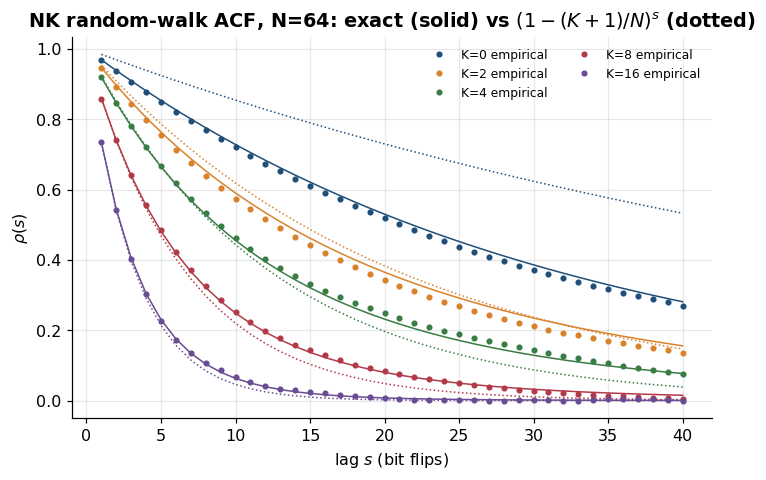

In [4]:
fig, ax = plt.subplots()
cols = [PALETTE[c] for c in ("blue", "orange", "green", "red", "purple")]
for K, col in zip(KS_W, cols):
    ax.plot(lags, acf_emp[K], "o", ms=3, color=col, label=f"K={K} empirical")
    ax.plot(lags, [rho_nk(s, N_W, K) for s in lags], "-", color=col, lw=1)
    ax.plot(lags, (1 - (K + 1) / N_W) ** lags, ":", color=col, lw=1)
ax.set(xlabel="lag $s$ (bit flips)", ylabel=r"$\rho(s)$",
       title=f"NK random-walk ACF, N={N_W}: exact (solid) vs $(1-(K+1)/N)^s$ (dotted)")
ax.legend(ncol=2, fontsize=8); savefig("w1_nk_acf.png"); plt.show()

The dotted approximation is visibly wrong for $K = 0$ (see the printed maximum deviation), where the finite-table
effect dominates, and drifts at long lags for larger $K$ because it ignores bits that are flipped back; the exact
expression matches within sampling error for all $K$. Ruggedness increases with $K$:
the correlation length falls roughly like $N/(K+1)$.

## 3. Number of local optima vs $K$ (exhaustive, $N = 16$)

**Proposition.** If the $2^N$ fitness values are i.i.d. continuous (NK with $K = N-1$), each point is a local maximum
with probability $1/(N+1)$ — it must be the largest among itself and its $N$ neighbours, and all orderings of $N+1$
i.i.d. values are equally likely — so $\mathbb{E}[\#\text{local optima}] = 2^N/(N+1)$. For $K = 0$ the landscape is
separable with a unique optimum and no other local optimum (every non-optimal bit can be improved independently).

In [5]:
N_EX = 16
X_ALL = all_bitstrings(N_EX)
NBR_ALL = bitflip_neighbours(N_EX)
KS = [0, 1, 2, 3, 4, 6, 8, 10, 12, 15]
N_INST = 5
n_lo = np.zeros((len(KS), N_INST))
fdc_nk = np.zeros((len(KS), N_INST))
t0 = time.perf_counter()
for a, K in enumerate(KS):
    for b in range(N_INST):
        f = NKLandscape(N_EX, K, rng)(X_ALL)
        n_lo[a, b] = np.sum(np.all(f[NBR_ALL] < f[:, None], axis=1))
        d = np.bitwise_count(np.arange(2**N_EX) ^ int(np.argmax(f)))      # Hamming distance to global optimum
        fdc_nk[a, b] = np.corrcoef(f, d)[0, 1]
print(f"exhaustive analysis of {len(KS) * N_INST} landscapes with 2^{N_EX} states in {time.perf_counter() - t0:.1f} s")
for K, row in zip(KS, n_lo):
    print(f"K={K:2d}: local optima mean {row.mean():8.1f} +- {row.std(ddof=1) / np.sqrt(N_INST):6.1f} (s.e.)")
check_true(np.all(n_lo[0] == 1), "K=0: exactly one local optimum in every instance")
expected_random = 2**N_EX / (N_EX + 1)
se = n_lo[-1].std(ddof=1) / np.sqrt(N_INST)
check_close(n_lo[-1].mean(), expected_random, f"K=N-1: mean #local optima = 2^N/(N+1)", atol=4 * se, rtol=0)
from scipy.stats import spearmanr
rho_k, p_k = spearmanr(np.repeat(KS, N_INST), n_lo.ravel())
print(f"Spearman correlation between K and #local optima over all {n_lo.size} landscapes: {rho_k:.3f} (p = {p_k:.1e})")
check_true(np.all(np.diff(n_lo.mean(axis=1)) > 0) and rho_k > 0.9 and p_k < 1e-6,
           "number of local optima increases with K (monotone means; rank correlation > 0.9, p < 1e-6)")

exhaustive analysis of 50 landscapes with 2^16 states in 18.0 s
K= 0: local optima mean      1.0 +-    0.0 (s.e.)
K= 1: local optima mean      6.0 +-    2.6 (s.e.)
K= 2: local optima mean     19.2 +-    3.1 (s.e.)
K= 3: local optima mean     80.6 +-   14.3 (s.e.)
K= 4: local optima mean    135.2 +-   10.9 (s.e.)
K= 6: local optima mean    356.0 +-    7.8 (s.e.)
K= 8: local optima mean    746.4 +-   22.0 (s.e.)
K=10: local optima mean   1413.4 +-   15.1 (s.e.)
K=12: local optima mean   2183.0 +-   14.6 (s.e.)
K=15: local optima mean   3864.8 +-   11.7 (s.e.)
[PASS] K=0: exactly one local optimum in every instance
[PASS] K=N-1: mean #local optima = 2^N/(N+1): got 3864.8, expected 3855.058824
Spearman correlation between K and #local optima over all 50 landscapes: 0.994 (p = 7.8e-48)
[PASS] number of local optima increases with K (monotone means; rank correlation > 0.9, p < 1e-6)


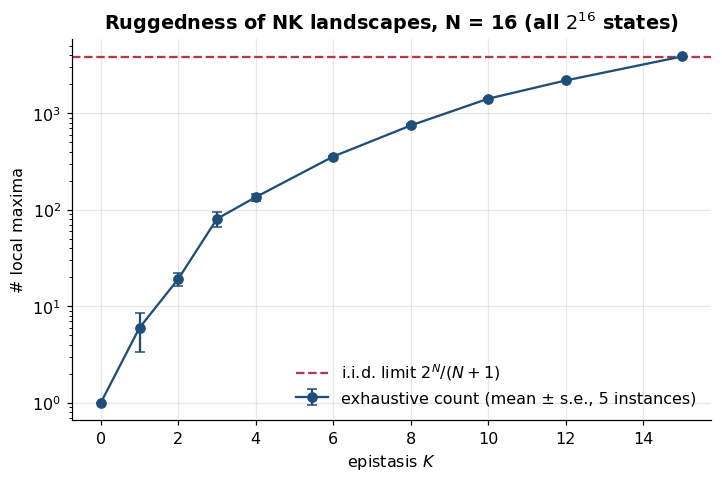

In [6]:
fig, ax = plt.subplots()
ax.errorbar(KS, n_lo.mean(axis=1), yerr=n_lo.std(axis=1, ddof=1) / np.sqrt(N_INST), fmt="o-",
            color=PALETTE["blue"], capsize=3, label="exhaustive count (mean ± s.e., 5 instances)")
ax.axhline(expected_random, ls="--", color=PALETTE["red"], label=r"i.i.d. limit $2^N/(N+1)$")
ax.set_yscale("log")
ax.set(xlabel="epistasis $K$", ylabel="# local maxima", title=f"Ruggedness of NK landscapes, N = {N_EX} (all $2^{{16}}$ states)")
ax.legend(); savefig("w1_nk_local_optima.png"); plt.show()

## 4. Fitness–distance correlation

Jones & Forrest (1995): with $d(x)$ the Hamming distance to the nearest global optimum,

$$\mathrm{FDC} = \frac{\mathrm{Cov}(f, d)}{\sigma_f\,\sigma_d}.$$

For **maximisation** the ideal value is $-1$ (fitness rises as the optimum approaches). Jones & Forrest's rule of thumb:
$\mathrm{FDC} \le -0.15$ "straightforward", $|\mathrm{FDC}| \lt 0.15$ "difficult", $\mathrm{FDC} \ge 0.15$ "misleading".
Test functions (maximised, over all of $\lbrace 0,1\rbrace^{12}$):
- **OneMax** $f(x) = u(x) = \sum_i x_i$: $d = N - u$ so $\mathrm{FDC} = -1$ exactly.
- **Fully deceptive trap** (Deb & Goldberg 1993): $f(x) = N$ if $u = N$, else $N - 1 - u$. The gradient of $u$ points to
  $0\cdots0$, away from the optimum $1\cdots1$.
- **Concatenated traps**: three 4-bit traps; deception acts inside each block.

For both functions of $u$ we get an independent closed form: $u \sim \mathrm{Bin}(N, 1/2)$ under uniform sampling, so
the FDC is a correlation of two functions of $u$ computed with binomial weights, without enumerating strings.

In [7]:
N_F = 12
Xf = all_bitstrings(N_F)
u = Xf.sum(axis=1)

def trap(uu, k):
    return np.where(uu == k, k, k - 1 - uu)

funcs = {
    "OneMax": u.astype(float),
    "trap (one 12-bit block)": trap(u, N_F).astype(float),
    "3 × 4-bit traps": sum(trap(Xf[:, 4 * b : 4 * b + 4].sum(axis=1), 4) for b in range(3)).astype(float),
}
fdc_vals = {}
for name, fv in funcs.items():
    opt = np.flatnonzero(fv == fv.max())
    d = np.min(np.bitwise_count(np.arange(2**N_F)[:, None] ^ opt[None, :]), axis=1)
    fdc_vals[name] = (pearsonr(fv, d)[0], fv, d)
    print(f"{name:26s} FDC = {fdc_vals[name][0]:+.4f}   (#global optima {len(opt)})")

def fdc_closed_form(g, N):
    """FDC when f = g(u) and d = N - u, using u ~ Binomial(N, 1/2)."""
    k = np.arange(N + 1); w = np.array([math.comb(N, i) for i in k]) / 2**N
    fk, dk = g(k).astype(float), (N - k).astype(float)
    cov = np.sum(w * fk * dk) - np.sum(w * fk) * np.sum(w * dk)
    return cov / np.sqrt((np.sum(w * fk**2) - np.sum(w * fk) ** 2) * (np.sum(w * dk**2) - np.sum(w * dk) ** 2))

check_close(fdc_vals["OneMax"][0], -1.0, "OneMax FDC = -1")
check_close(fdc_vals["OneMax"][0], fdc_closed_form(lambda k: k, N_F), "OneMax FDC: enumeration = binomial closed form")
check_close(fdc_vals["trap (one 12-bit block)"][0], fdc_closed_form(lambda k: trap(k, N_F), N_F),
            "trap FDC: enumeration = binomial closed form")
check_true(fdc_vals["trap (one 12-bit block)"][0] > 0.15, "the full trap is 'misleading' (FDC >= 0.15)")
for K, row in zip(KS, fdc_nk):
    print(f"NK N={N_EX}, K={K:2d}: FDC = {row.mean():+.3f} +- {row.std(ddof=1) / np.sqrt(N_INST):.3f}")
check_true(fdc_nk[0].mean() < fdc_nk[-1].mean(), "NK: FDC moves toward 0 as K grows")

OneMax                     FDC = -1.0000   (#global optima 1)
trap (one 12-bit block)    FDC = +0.9931   (#global optima 1)
3 × 4-bit traps            FDC = +0.3402   (#global optima 1)
[PASS] OneMax FDC = -1: got -1.0, expected -1.0
[PASS] OneMax FDC: enumeration = binomial closed form: got -1.0, expected -1.0
[PASS] trap FDC: enumeration = binomial closed form: got 0.993129, expected 0.993129
[PASS] the full trap is 'misleading' (FDC >= 0.15)
NK N=16, K= 0: FDC = -0.847 +- 0.023
NK N=16, K= 1: FDC = -0.595 +- 0.058
NK N=16, K= 2: FDC = -0.337 +- 0.088
NK N=16, K= 3: FDC = -0.185 +- 0.034
NK N=16, K= 4: FDC = -0.138 +- 0.032
NK N=16, K= 6: FDC = -0.028 +- 0.022
NK N=16, K= 8: FDC = -0.019 +- 0.006
NK N=16, K=10: FDC = +0.006 +- 0.005
NK N=16, K=12: FDC = +0.000 +- 0.006
NK N=16, K=15: FDC = +0.000 +- 0.001
[PASS] NK: FDC moves toward 0 as K grows


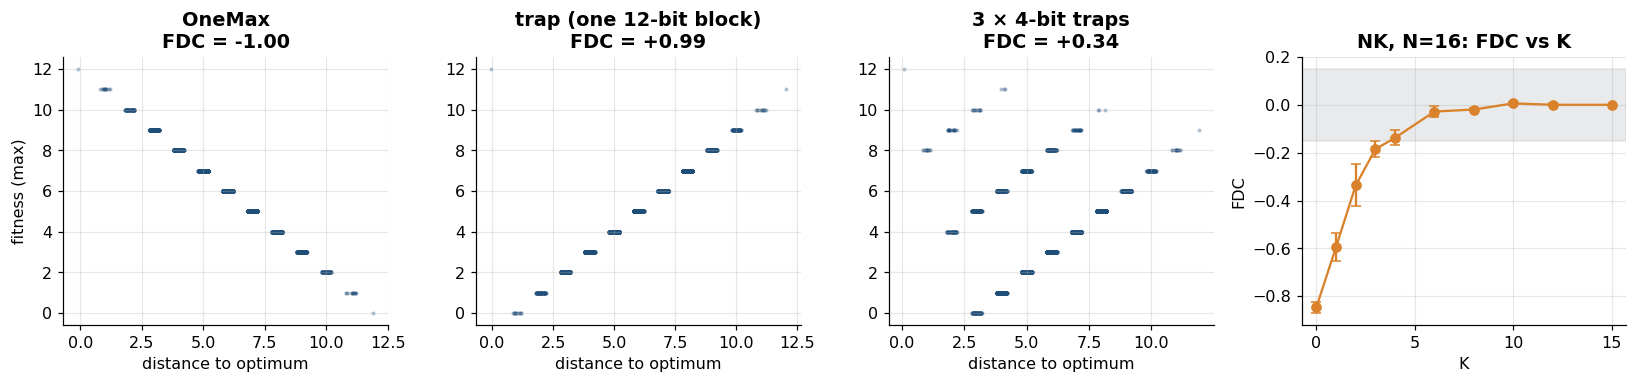

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (name, (r, fv, d)) in zip(axes[:3], fdc_vals.items()):
    jit = rng.uniform(-0.2, 0.2, len(d))
    ax.scatter(d + jit, fv, s=3, alpha=0.25, color=PALETTE["blue"])
    ax.set(title=f"{name}\nFDC = {r:+.2f}", xlabel="distance to optimum")
axes[0].set_ylabel("fitness (max)")
axes[3].errorbar(KS, fdc_nk.mean(axis=1), yerr=fdc_nk.std(axis=1, ddof=1) / np.sqrt(N_INST), fmt="o-",
                 color=PALETTE["orange"], capsize=3)
axes[3].axhspan(-0.15, 0.15, color=PALETTE["grey"], alpha=0.15)
axes[3].set(title=f"NK, N={N_EX}: FDC vs K", xlabel="K", ylabel="FDC")
fig.tight_layout(); savefig("w1_fdc.png"); plt.show()

FDC is informative but not a complete difficulty measure: Altenberg (1997) and Quick, Rayward-Smith & Smith (1998)
built counterexamples in both directions, and it needs the optimum, so it is an *analysis* tool for benchmark design,
not something an algorithm can compute on-line.

## 5. Local optima networks

The **local optima network** (LON; Ochoa, Tomassini, Vérel & Darabos 2008) compresses a landscape into a graph whose
nodes are the local optima. Here we use **escape edges** (Vérel, Daolio, Ochoa & Tomassini 2011): there is an edge
$a \to b$ with weight $w_{ab}$ = number of points $y$ with $1 \le d(y, a) \le 2$ whose best-improvement descent ends
at $b$. This models an iterated local search with a 2-bit perturbation (Week 3), and asks: from which optima can such
a search reach the global one?

In [9]:
N_L, K_L = 10, 4
nkl = NKLandscape(N_L, K_L, np.random.default_rng(7))
fl = nkl(all_bitstrings(N_L))
nbl = bitflip_neighbours(N_L)
st = np.arange(2**N_L)
step = np.where(fl[nbl].max(axis=1) > fl, nbl[st, np.argmax(fl[nbl], axis=1)], st)   # one best-improvement step
att = step.copy()
while not np.array_equal(att[att], att):
    att = att[att]
optima = np.flatnonzero(np.all(fl[nbl] < fl[:, None], axis=1))
check_true(np.array_equal(np.unique(att), optima), "attractors of best-improvement descent = local maxima")
node = {o: k for k, o in enumerate(optima)}
pert = [1 << i for i in range(N_L)] + [(1 << i) | (1 << j) for i in range(N_L) for j in range(i + 1, N_L)]
W = np.zeros((len(optima), len(optima)), dtype=int)
for o in optima:
    for p in pert:
        W[node[o], node[att[o ^ p]]] += 1
check_true(np.all(W.sum(axis=1) == len(pert)), f"each node has {len(pert)} escape trials (N + N(N-1)/2)")
g_node = node[int(np.argmax(fl))]

def reaches(W, target):
    """Nodes with a directed path to target (reverse BFS)."""
    seen, frontier = {target}, [target]
    while frontier:
        v = frontier.pop()
        for u_ in np.flatnonzero(W[:, v] > 0):
            if u_ not in seen:
                seen.add(int(u_)); frontier.append(int(u_))
    return seen

reach = reaches(W, g_node)
basin_l = np.array([np.sum(att == o) for o in optima])
self_loop = np.diag(W) / len(pert)
print(f"LON of NK(N={N_L}, K={K_L}): {len(optima)} local optima, {np.count_nonzero(W) - np.count_nonzero(np.diag(W))} escape edges")
print(f"optima with a path to the global optimum: {len(reach)}/{len(optima)};  "
      f"median probability that a random 2-bit kick returns to the same optimum: {np.median(self_loop):.2f}")

[PASS] attractors of best-improvement descent = local maxima
[PASS] each node has 55 escape trials (N + N(N-1)/2)
LON of NK(N=10, K=4): 25 local optima, 203 escape edges
optima with a path to the global optimum: 25/25;  median probability that a random 2-bit kick returns to the same optimum: 0.29


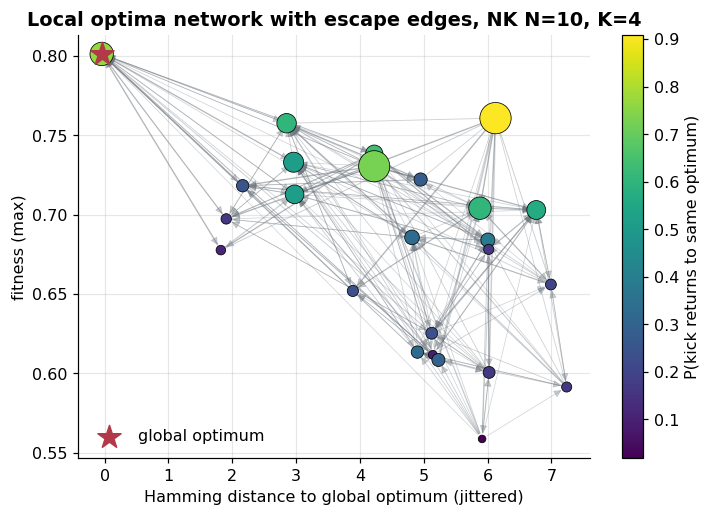

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5))
dist = np.bitwise_count(optima ^ optima[g_node])
xy = np.c_[dist + np.random.default_rng(1).uniform(-0.25, 0.25, len(optima)), fl[optima]]
for a in range(len(optima)):
    for b in range(len(optima)):
        if a != b and W[a, b] > 0:
            ax.annotate("", xy=xy[b], xytext=xy[a],
                        arrowprops=dict(arrowstyle="-|>", lw=0.4 + 2 * W[a, b] / len(pert), alpha=0.35,
                                        color=PALETTE["grey"], shrinkA=4, shrinkB=4))
sc = ax.scatter(xy[:, 0], xy[:, 1], s=20 + 400 * basin_l / basin_l.max(), c=self_loop, cmap="viridis", zorder=3,
                edgecolor="k", lw=0.5)
ax.scatter(*xy[g_node], s=250, marker="*", color=PALETTE["red"], zorder=4, label="global optimum")
plt.colorbar(sc, ax=ax, label="P(kick returns to same optimum)")
ax.set(xlabel="Hamming distance to global optimum (jittered)", ylabel="fitness (max)",
       title=f"Local optima network with escape edges, NK N={N_L}, K={K_L}")
ax.legend(loc="lower left"); savefig("w1_lon.png"); plt.show()

## 6. Continuous landscapes: Rastrigin vs Sphere

The same tool applies in $\mathbb{R}^d$ with a Gaussian random walk $x_{t+1} = x_t + \sigma z_t$ (reflected at the box
boundary, whose stationary distribution is uniform). Rastrigin is Sphere plus an oscillation:
$f(x) = \sum_i x_i^2 + 10\sum_i\big(1-\cos 2\pi x_i\big)$. For the cosine part alone, with increment
$\delta \sim \mathcal{N}(0, s\sigma^2)$ after $s$ steps and $x$ uniform over whole periods,

$$\rho_{\cos}(s) = \mathbb{E}\cos(2\pi\delta) = e^{-2\pi^2\sigma^2 s},$$

while the quadratic part decorrelates only on the diffusive time scale $(u-\ell)^2/\sigma^2$. So Rastrigin's ACF should
drop fast to a slowly decaying plateau of the order of the variance share of the quadratic part — a two-scale ruggedness
that a single correlation length hides. (The plateau lies somewhat *below* that share: the quadratic part keeps
decorrelating slowly, and the negative covariance between the quadratic and cosine parts also enters.)

In [11]:
def gaussian_walk(d, L, sigma, lo, hi, rng):
    X = np.empty((L, d)); x = rng.uniform(lo, hi, d)
    Z = sigma * rng.standard_normal((L, d))
    for t in range(L):
        x = x + Z[t]
        x = np.where(x > hi, 2 * hi - x, x); x = np.where(x < lo, 2 * lo - x, x)   # reflect
        X[t] = x
    return X

D_C, L_C, SIG, LAGS_C = 10, 60000, 0.05, 200
Xw = gaussian_walk(D_C, L_C, SIG, -5.12, 5.12, rng)
acf_sph = acf(sphere(Xw), LAGS_C)
acf_ras = acf(rastrigin(Xw), LAGS_C)
acf_cos = acf(np.sum(np.cos(2 * np.pi * Xw), axis=1), LAGS_C)
lc = np.arange(1, LAGS_C + 1)
# standard error of the ACF from 6 segments of the walk (batch means; segments are ~300 correlation times long)
seg_acf = np.array([acf(seg, 30) for seg in np.split(np.sum(np.cos(2 * np.pi * Xw), axis=1), 6)])
se_cos = (seg_acf.std(axis=0, ddof=1) / np.sqrt(6)).max()
check_close(np.abs(acf_cos[:30] - np.exp(-2 * np.pi**2 * SIG**2 * lc[:30])).max(), 0.0,
            f"cosine component: max |ACF - exp(-2 pi^2 sigma^2 s)| over lags 1..30 within 5 s.e. = {5 * se_cos:.3f}",
            atol=5 * se_cos, rtol=0)
share_quad = np.var(np.sum(Xw**2, 1)) / np.var(rastrigin(Xw))
print(f"variance share of the quadratic part in Rastrigin along the walk: {share_quad:.2f}")
print(f"rho(10):  sphere {acf_sph[9]:.3f}   rastrigin {acf_ras[9]:.3f};   rho(100): sphere {acf_sph[99]:.3f}   rastrigin {acf_ras[99]:.3f}")
check_true(np.all(acf_ras[:LAGS_C] < acf_sph[:LAGS_C]), "Rastrigin is more rugged than Sphere at every lag")

[PASS] cosine component: max |ACF - exp(-2 pi^2 sigma^2 s)| over lags 1..30 within 5 s.e. = 0.074: got 0.035374, expected 0.0
variance share of the quadratic part in Rastrigin along the walk: 0.67
rho(10):  sphere 0.995   rastrigin 0.846;   rho(100): sphere 0.953   rastrigin 0.579
[PASS] Rastrigin is more rugged than Sphere at every lag


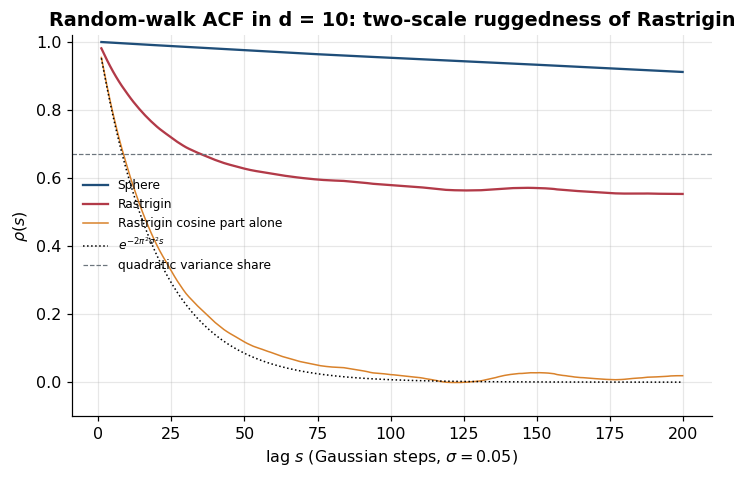

In [12]:
fig, ax = plt.subplots()
ax.plot(lc, acf_sph, color=PALETTE["blue"], label="Sphere")
ax.plot(lc, acf_ras, color=PALETTE["red"], label="Rastrigin")
ax.plot(lc, acf_cos, color=PALETTE["orange"], lw=1, label=r"Rastrigin cosine part alone")
ax.plot(lc, np.exp(-2 * np.pi**2 * SIG**2 * lc), "k:", lw=1, label=r"$e^{-2\pi^2\sigma^2 s}$")
ax.axhline(share_quad, color=PALETTE["grey"], ls="--", lw=0.8, label="quadratic variance share")
ax.set(xlabel="lag $s$ (Gaussian steps, $\\sigma = 0.05$)", ylabel=r"$\rho(s)$", ylim=(-0.1, 1.02),
       title=f"Random-walk ACF in d = {D_C}: two-scale ruggedness of Rastrigin")
ax.legend(fontsize=8); savefig("w1_continuous_acf.png"); plt.show()

## 7. A remark on neutrality

Many real landscapes have **plateaus**: neighbours with *equal* fitness. Neutral networks (connected sets of equal
fitness) let a search drift without selection pressure; they arise from redundant encodings (random keys, Notebook 2),
from integer-valued objectives (MAX-SAT counts satisfied clauses), and in genotype–phenotype maps of genetic
programming and RNA folding. Variants of NK that add neutrality are NK$p$ (Barnett 1998) and NK$q$ (Newman &
Engelhardt 1998). Below: the fraction of neutral bit flips in random MAX-3SAT near the satisfiability threshold
(clause/variable ratio 4.26), at random points and at the end of a hill-climbing run.

In [13]:
n_var, n_cl = 60, 256
cls = random_max3sat(n_var, n_cl, rng)

def neutral_fraction(x):
    base = count_satisfied(x, cls)
    vals = []
    for i in range(n_var):
        y = x.copy(); y[i] = ~y[i]; vals.append(count_satisfied(y, cls))
    return np.mean(np.array(vals) == base), np.array(vals), base

rand_frac, lo_frac = [], []
for _ in range(20):
    x = rng.random(n_var) < 0.5
    rand_frac.append(neutral_fraction(x)[0])
    while True:                                                     # best-improvement ascent (strict)
        frac, vals, base = neutral_fraction(x)
        if vals.max() <= base:
            break
        x[int(np.argmax(vals))] ^= True
    lo_frac.append(frac)
print(f"neutral fraction of bit flips: random assignments {np.mean(rand_frac):.2f} +- {np.std(rand_frac, ddof=1) / np.sqrt(20):.2f};"
      f"  at strict-ascent local optima {np.mean(lo_frac):.2f} +- {np.std(lo_frac, ddof=1) / np.sqrt(20):.2f}")
on_plateau = np.mean(np.array(lo_frac) > 0)
print(f"fraction of ascent end points with at least one sideways (neutral) move: {on_plateau:.2f}")
check_true(on_plateau > 0.5, "most MAX-SAT 'local optima' are non-strict: they sit on plateaus with sideways moves")
check_true(np.all(np.min(np.abs(fl[nbl] - fl[:, None]), axis=1) > 0), "contrast: NK with continuous tables has no neutral moves")

neutral fraction of bit flips: random assignments 0.24 +- 0.01;  at strict-ascent local optima 0.18 +- 0.01
fraction of ascent end points with at least one sideways (neutral) move: 1.00
[PASS] most MAX-SAT 'local optima' are non-strict: they sit on plateaus with sideways moves
[PASS] contrast: NK with continuous tables has no neutral moves


Neutral moves are common everywhere in MAX-SAT, and they survive at the end of strict ascent: the points where
hill climbing stops are typically not strict local optima but sit on plateaus from which sideways moves may lead to
improvements. This is why successful SAT local search (GSAT, Selman, Levesque & Mitchell 1992; WalkSAT, Selman,
Kautz & Cohen 1994) accepts sideways moves. NK landscapes with continuous tables, by contrast, have no neutrality at all.

## Key takeaways
- A landscape is $(S, N, f)$; ruggedness, deception and neutrality are properties of the triple, and they can be
  *measured*.
- The NK random-walk ACF has an exact form $\rho(s) = (M P_0(s) - 1)/(M-1)$, which our walks matched within 5 standard errors; the
  textbook $(1-(K+1)/N)^s$ is its large-$K$, short-lag approximation. Correlation length shrinks roughly like $N/(K+1)$.
- Exhaustive enumeration of all $2^{16}$ states showed the number of local optima growing from exactly 1 ($K=0$) to the
  i.i.d. limit $2^N/(N+1)$ ($K=N-1$).
- FDC is $-1$ for OneMax and positive for deceptive traps (both matched binomial closed forms); for NK it drifts toward
  0 as $K$ grows.
- Local optima networks summarise global structure (who can reach the optimum under a given perturbation) — the
  landscape seen by iterated local search.
- Continuous landscapes can be rugged at one scale and smooth at another: Rastrigin's ACF decays fast to a plateau.

## Exercises
1. ★ Prove that $P_0(1) = 1 - (K+1)/N$ exactly, and derive $\rho(1)$ for NK landscapes with *adjacent* neighbourhoods.
   Does the ACF depend on the neighbourhood model?
2. ★ Show that for OneMax the FDC is exactly $-1$ for any $N$, and compute the FDC of LeadingOnes in closed form.
3. ★★ Prove that the expected number of local optima of NK with $K = N-1$ is $2^N/(N+1)$ and compute its *variance*
   (hint: pairs of neighbouring points cannot both be local optima). Compare with the exhaustive data.
4. ★★ Implement NK$q$ ($q$ distinct table values) and measure how the number of *strict* local optima and the size of
   neutral networks change with $q$ for $N=14$.
5. ★★ Replace the escape-edge LON by a *basin-transition* LON (Ochoa et al. 2008): the weight $a\to b$ is the
   probability that a random bit flip from a point in basin $a$ lands in basin $b$. Compare both networks on the same
   landscape.
6. ★★★ Derive the random-walk ACF of the Sphere function under the reflected Gaussian walk and explain the slow decay
   seen in the figure; then design a continuous function whose ACF is exactly exponential with a prescribed
   correlation length.